# Look Original Data

In [1]:
import polars as pl
import numpy as np

In [2]:
# 查看原始数据，为什么 MIC-guide graph 计算完成后只保留了13个特征
path_parq = "/mnt/bank/scPlantDB/ath/mic_g_init/DRP009643.h5ad.parquet"

In [3]:
df1 = pl.read_parquet(path_parq)

In [4]:
print(df1)

shape: (15_400, 53_679)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ obs_names ┆ AT1G01010 ┆ AT1G01020 ┆ AT1G01030 ┆ … ┆ ATMG01275 ┆ ATMG01320 ┆ ATMG01320 ┆ ATMG0136 │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ -2        ┆ ---       ┆ 0        │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ ---       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆ f64       ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ DRX382001 ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ @@_AAACCC ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ AAGAGATCG ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ C-1       ┆           ┆           ┆           ┆   ┆           ┆  

# Try CV 变异系数

In [5]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:

path_parq = "/mnt/bank/scPlantDB/ath/mic_g_init/SRP338044.h5ad.parquet"


In [10]:
mat_sc = pl.read_parquet(path_parq)
print(mat_sc)
mat_sc_np = mat_sc.drop(["obs_names"]).to_numpy()


shape: (50_418, 53_679)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ obs_names ┆ AT1G01010 ┆ AT1G01020 ┆ AT1G01030 ┆ … ┆ ATMG01275 ┆ ATMG01320 ┆ ATMG01320 ┆ ATMG0136 │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ -2        ┆ ---       ┆ 0        │
│ str       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ ---       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆ f64       ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ SRX122807 ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ 95@@_AAAC ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ CCAAGAGCC ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ ATG…      ┆           ┆           ┆           ┆   ┆           ┆  

In [13]:
# Compute coefficient of variation of each column
mean_values = np.mean(mat_sc_np, axis=0)
std_values = np.std(mat_sc_np, axis=0)


In [16]:
cv = np.where(np.abs(mean_values) > 1e-6, std_values / mean_values, 0)
print(cv)


[18.42992572  6.34968281 13.58266027 ...  0.          0.
  0.        ]


/tmp/ipykernel_2641621/1117267716.py:1: RuntimeWarning: invalid value encountered in divide
  cv = np.where(np.abs(mean_values) > 1e-6, std_values / mean_values, 0)


## Plot histogram of CV

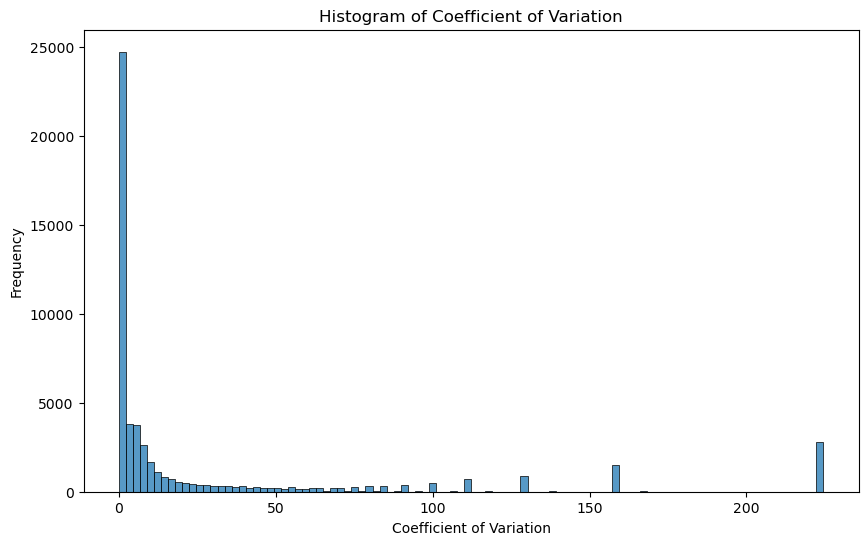

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(cv, bins=100)
plt.title("Histogram of Coefficient of Variation")
plt.xlabel("Coefficient of Variation")
plt.ylabel("Frequency")
plt.show()


# See results

In [2]:
path_r1 = "/mnt/bank/scPlantDB/ath/mic_g_init/results/CRA002977_1.h5ad.parquet"

In [1]:
import polars as pl
import numpy as np

In [3]:
df_r1 = pl.read_parquet(path_r1)

In [4]:
print(df_r1.shape)

(10947, 2706)
